## 1. Thư viện cần thiết

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import random

In [2]:
# Đường lnk lấy dataset
axial_train_dataset = '/kaggle/input/brain-tumor-by-plane-object-detection/axial_t1wce_2_class/train/'
coronal_train_dataset = '/kaggle/input/brain-tumor-by-plane-object-detection/coronal_t1wce_2_class/train/'
sagittal_train_dataset = '/kaggle/input/brain-tumor-by-plane-object-detection/sagittal_t1wce_2_class/train/'
axial_test_dataset = '/kaggle/input/brain-tumor-by-plane-object-detection/axial_t1wce_2_class/test/'
coronal_test_dataset = '/kaggle/input/brain-tumor-by-plane-object-detection/coronal_t1wce_2_class/test/'
sagittal_test_dataset = '/kaggle/input/brain-tumor-by-plane-object-detection/sagittal_t1wce_2_class/test/'

## 2. Cắt bỏ phần nền đen, giữ lại phần não

In [9]:
def crop_images_with_bounding_box(image_list, label_files_list, label_dir, output_label_dir):
    cropped_images = []

    # Tạo thư mục đầu ra nếu chưa có
    if not os.path.exists(output_label_dir):
        os.makedirs(output_label_dir)

    for img, label_file in zip(image_list, label_files_list):
        label_path = os.path.join(label_dir, label_file)
        output_label_path = os.path.join(output_label_dir, label_file)

        # Đọc nội dung file nhãn
        with open(label_path, 'r') as f:
            labels = [list(map(float, line.strip().split())) for line in f.readlines()]

        # Ngưỡng Otsu để cắt hình ảnh
        thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
        hh, ww = thresh.shape

        # Làm đen hai hàng cuối cùng của ảnh nhị phân
        thresh[hh-3:hh, 0:ww] = 0

        # Tìm giới hạn của các pixel trắng
        white = np.where(thresh == 255)
        if white[0].size > 0:  # Kiểm tra xem có pixel trắng không
            xmin, ymin, xmax, ymax = np.min(white[1]), np.min(white[0]), np.max(white[1]), np.max(white[0])

            # Cắt ảnh gốc theo các giới hạn
            crop = img[ymin:ymax + 3, xmin:xmax]
            cropped_images.append(crop)

            # Điều chỉnh bounding boxes cho phù hợp với hình ảnh đã cắt
            new_labels = []
            for label in labels:
                label_class = int(label[0])  # Nhãn là kiểu int
                x_center, y_center, width, height = label[1:]

                # Tính lại tọa độ dựa trên phần cắt
                new_x_center = (x_center * ww - xmin) / (xmax - xmin)
                new_y_center = (y_center * hh - ymin) / (ymax - ymin)
                new_width = width * ww / (xmax - xmin)
                new_height = height * hh / (ymax - ymin)

                # Lưu lại nhãn sau khi điều chỉnh
                new_labels.append([label_class, new_x_center, new_y_center, new_width, new_height])

            # Ghi nhãn mới vào file trong thư mục output
            with open(output_label_path, 'w') as f_out:
                for new_label in new_labels:
                    # Ghi nhãn với định dạng label (int) và các tọa độ bounding box (float)
                    f_out.write(f"{int(new_label[0])} {' '.join(map(lambda x: f'{x:.6f}', new_label[1:]))}\n")

        else:
            # Nếu không có pixel trắng, giữ nguyên ảnh và nhãn, ghi lại nhãn cũ
            cropped_images.append(img)
            with open(output_label_path, 'w') as f_out:
                for label in labels:
                    # Ghi nhãn gốc với định dạng label (int) và tọa độ bounding box (float)
                    f_out.write(f"{int(label[0])} {' '.join(map(lambda x: f'{x:.6f}', label[1:]))}\n")

    return cropped_images

In [10]:
# Cắt bỏ trên tập train
axial_image_train_crop = crop_images_with_bounding_box(axial_image_train, axial_labels_train, axial_train_dataset + "labels", "/kaggle/working/brain_tumor_object_detection/axial/train/labels")
coronal_image_train_crop = crop_images_with_bounding_box(coronal_image_train, coronal_labels_train, coronal_train_dataset + "labels", "/kaggle/working/brain_tumor_object_detection/coronal/train/labels")
sagittal_image_train_crop = crop_images_with_bounding_box(sagittal_image_train, sagittal_labels_train, sagittal_train_dataset + "labels", "/kaggle/working/brain_tumor_object_detection/sagittal/train/labels")

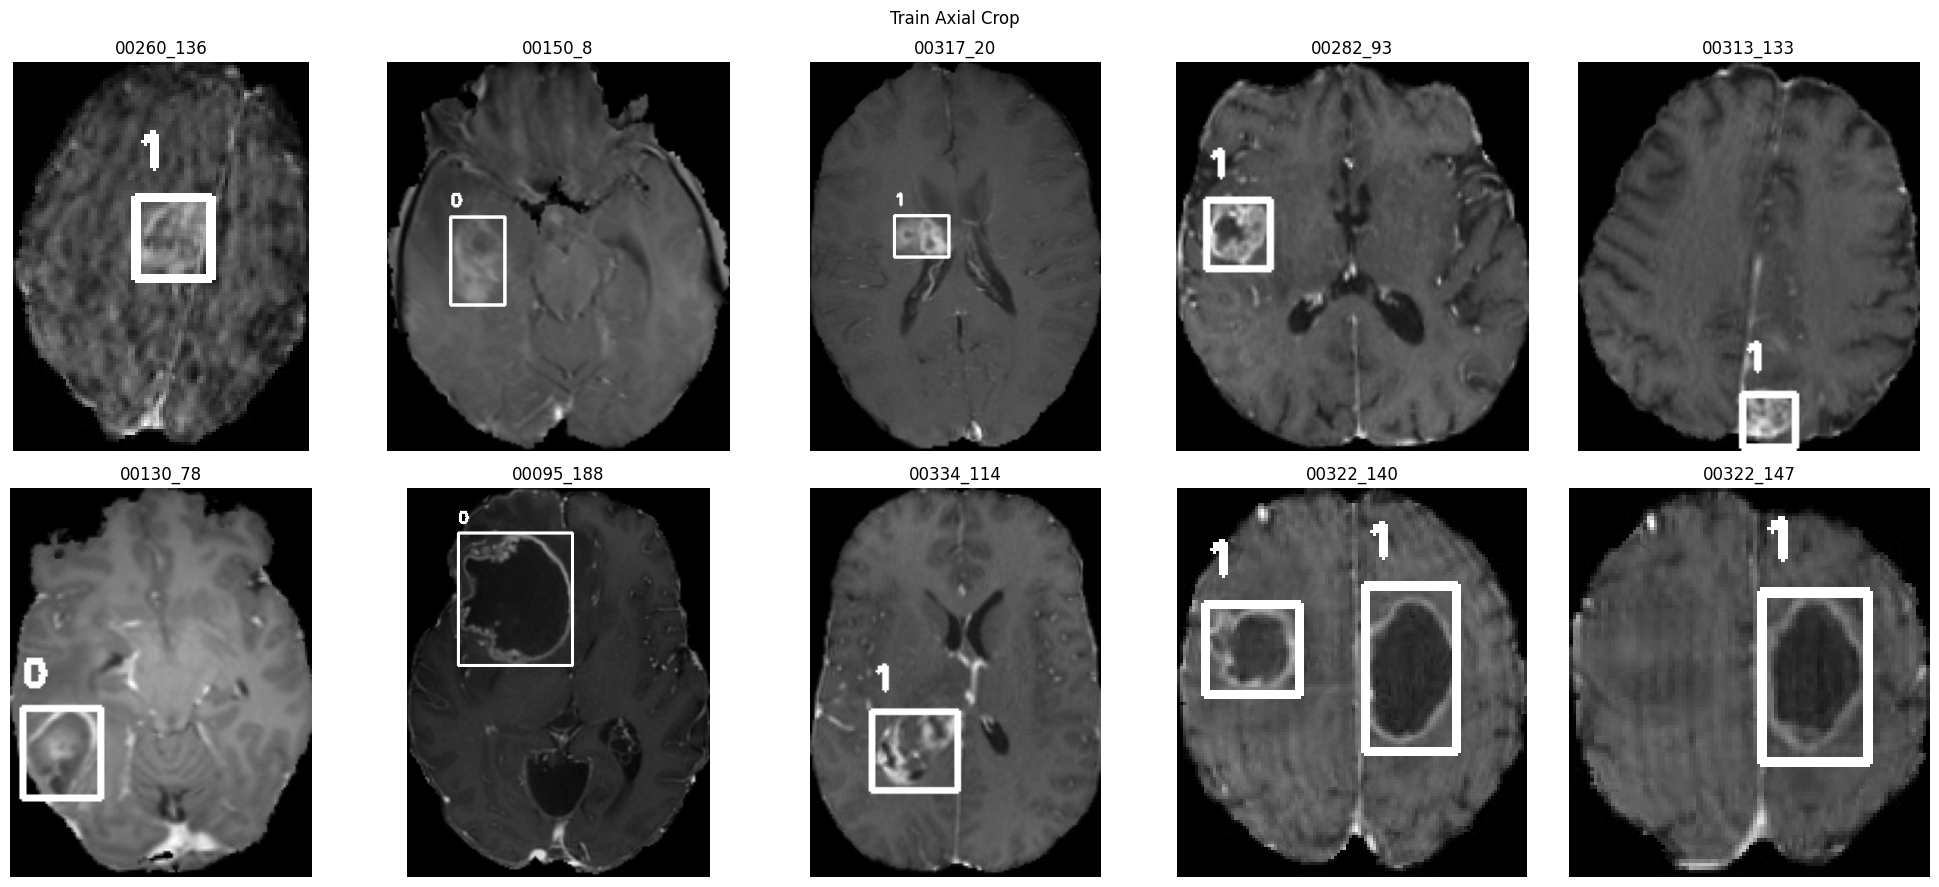

In [11]:
plot_images_with_bboxes(axial_image_train_crop, axial_labels_train,  "/kaggle/working/brain_tumor_object_detection/axial/train/labels", "Train Axial Crop")

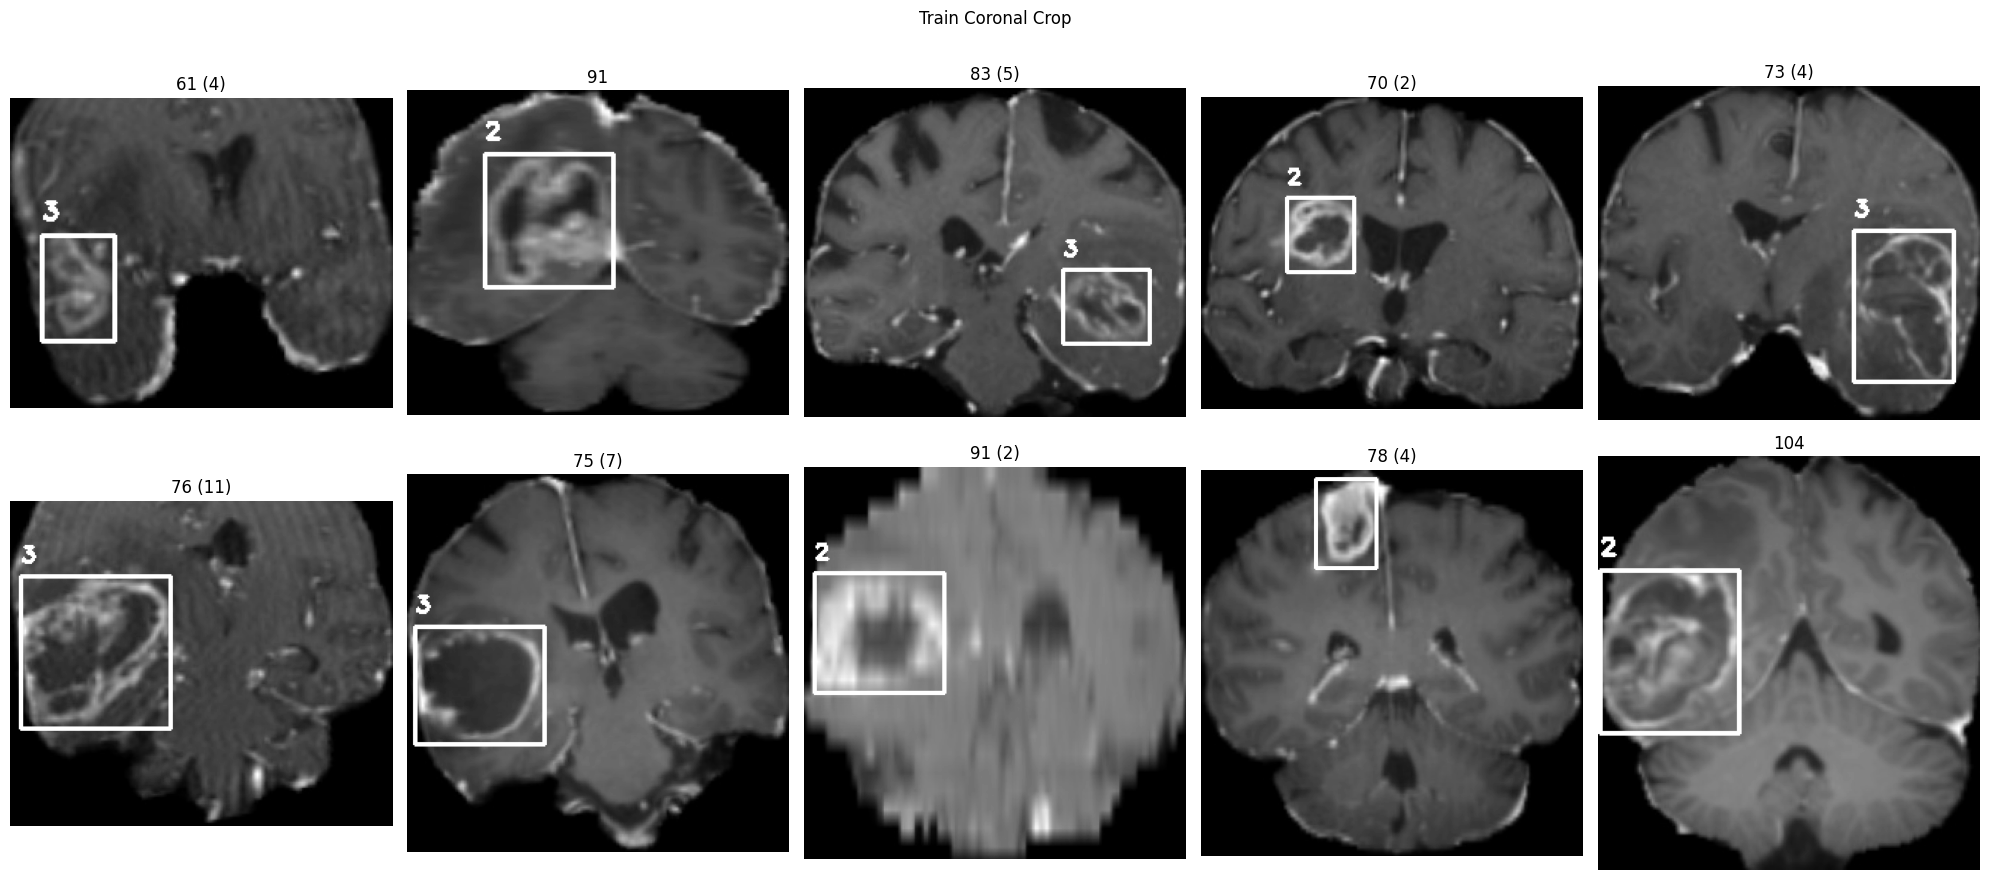

In [12]:
plot_images_with_bboxes(coronal_image_train_crop, coronal_labels_train,  "/kaggle/working/brain_tumor_object_detection/coronal/train/labels", "Train Coronal Crop")

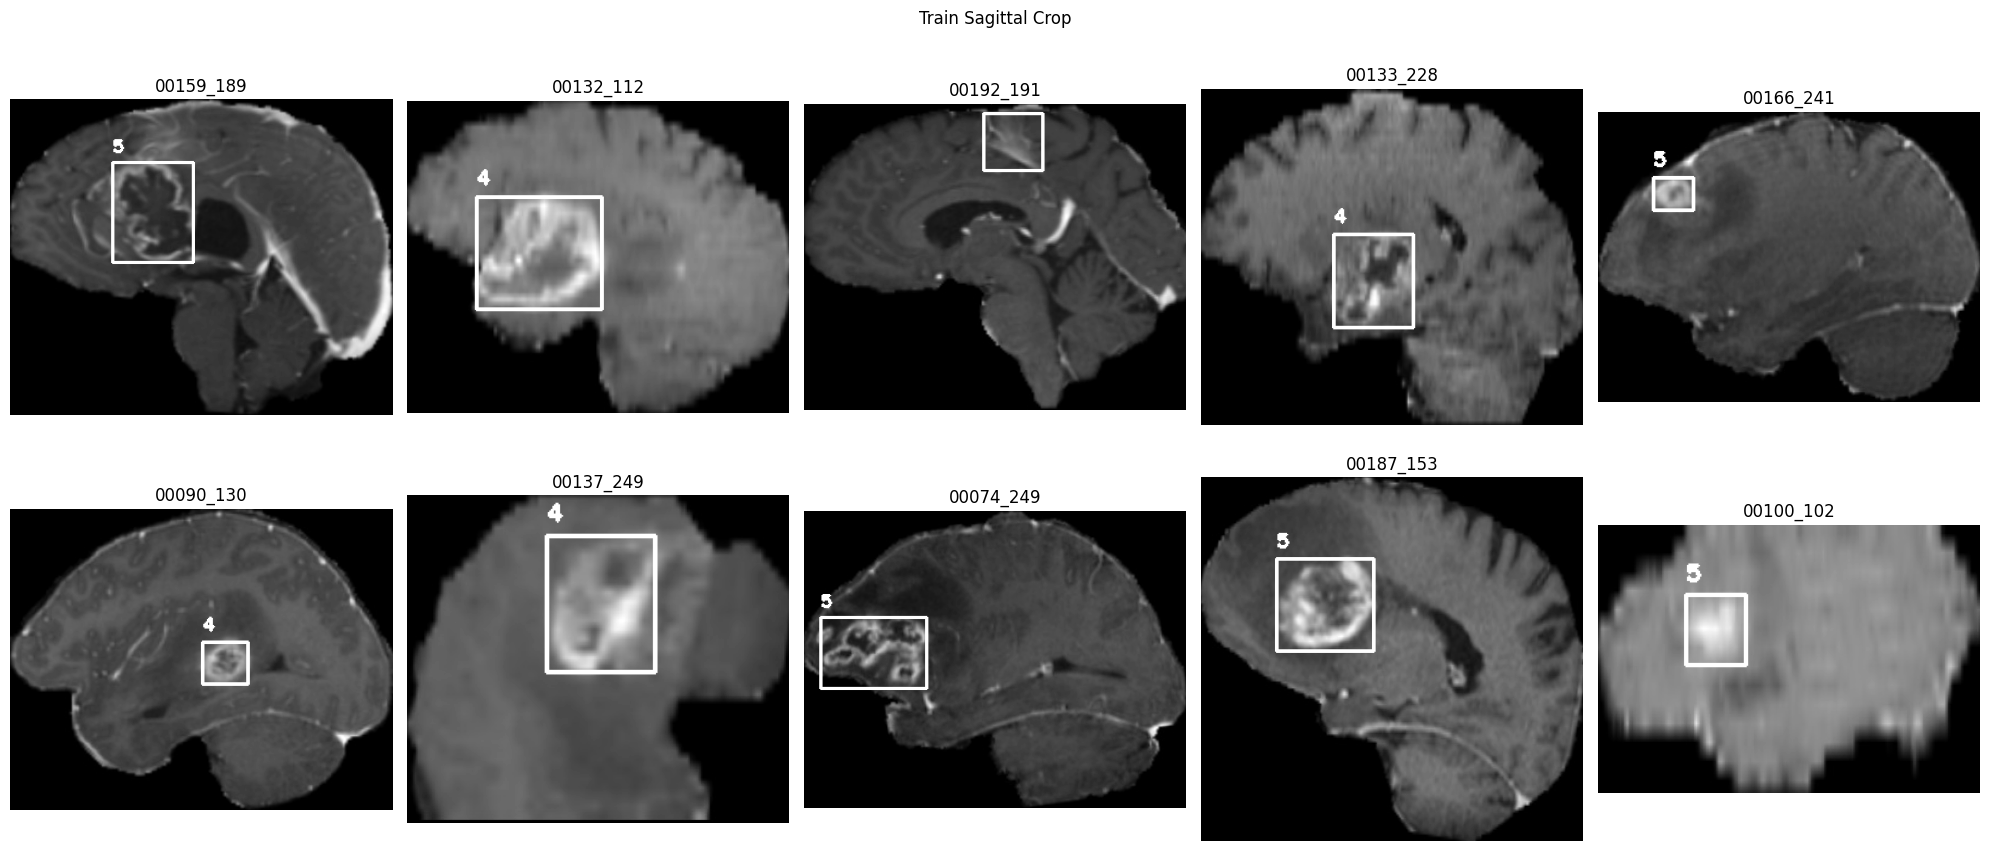

In [13]:
plot_images_with_bboxes(sagittal_image_train_crop, sagittal_labels_train,  "/kaggle/working/brain_tumor_object_detection/sagittal/train/labels", "Train Sagittal Crop")

In [14]:
# Cắt bỏ trên tập test
axial_image_test_crop = crop_images_with_bounding_box(axial_image_test, axial_labels_test, axial_test_dataset + "labels", "/kaggle/working/brain_tumor_object_detection/axial/train/labels")
coronal_image_test_crop = crop_images_with_bounding_box(coronal_image_test, coronal_labels_test, coronal_test_dataset + "labels", "/kaggle/working/brain_tumor_object_detection/coronal/train/labels")
sagittal_image_test_crop = crop_images_with_bounding_box(sagittal_image_test, sagittal_labels_test, sagittal_test_dataset + "labels", "/kaggle/working/brain_tumor_object_detection/sagittal/train/labels")

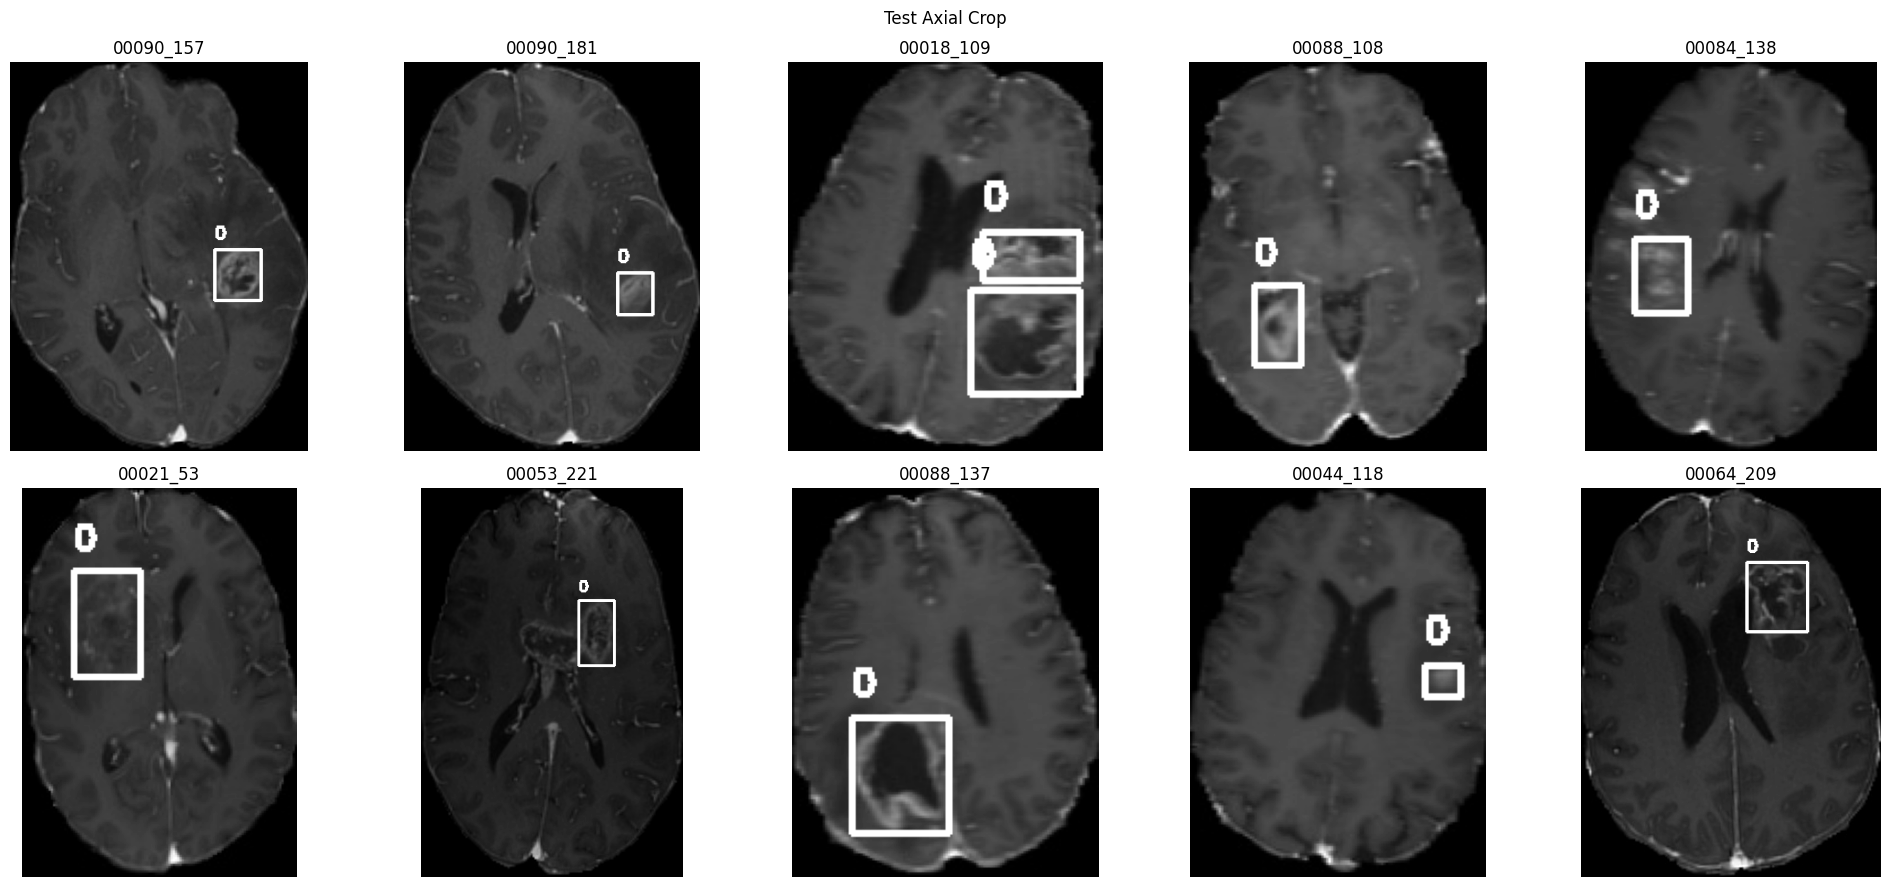

In [15]:
plot_images_with_bboxes(axial_image_test_crop, axial_labels_test,  "/kaggle/working/brain_tumor_object_detection/axial/train/labels", "Test Axial Crop")